## Day 5 — Supervised-Learning Mini-Project 

In [81]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### task1: Choose a provided dataset and determine whether the task is regression or classification.

In [82]:
df = pd.read_csv('Housing Prices/housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### Task Determination: Regression

This is a **regression** task — `median_house_value` is a continuous dollar 
amount, not a category. Use regression models (e.g. `LinearRegression`) and 
metrics (MAE, RMSE, R²).

**Features (X):** longitude, latitude, housing_median_age, total_rooms, 
total_bedrooms, population, households, median_income, ocean_proximity
**Target (y):** median_house_value

### task2: Perform brief EDA, then preprocess: handle missing values, encode categoricals, and scale features (fit on train only).

In [83]:
# --- Brief EDA ---
print(df.shape)
print(df.info())
print(df.describe())


(20640, 10)
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB
None
          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952   

In [84]:
print(df.isnull().sum())


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [85]:
df['total_bedrooms'].isnull().sum()

np.int64(207)

In [86]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

In [87]:
df['total_bedrooms'].isnull().sum()

np.int64(0)

### EDA Findings

- **Shape:** 20,640 rows × 10 columns
- **Types:** all numeric except `ocean_proximity` (categorical)
- **Missing values:** `total_bedrooms` has 207 missing; all others complete
- **Stats:** longitude/latitude tightly clustered (California only); income 
  and house value show wide, expected variation

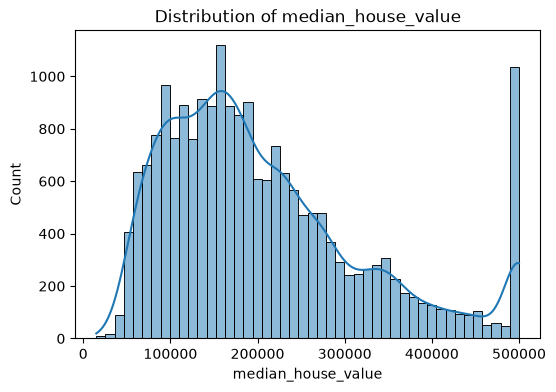

In [88]:
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='median_house_value', kde=True)
plt.title("Distribution of median_house_value")
plt.show()


### Distribution of `median_house_value`

**Right-skewed**, concentrated between $100K-$250K with a long tail.

**Notable:** a spike at exactly $500,000 — likely a **capping artifact** 
(values above $500K clipped to that number), not a true outlier.

**Implication:** consider dropping or flagging capped rows rather than 
treating them as normal high-value outliers.

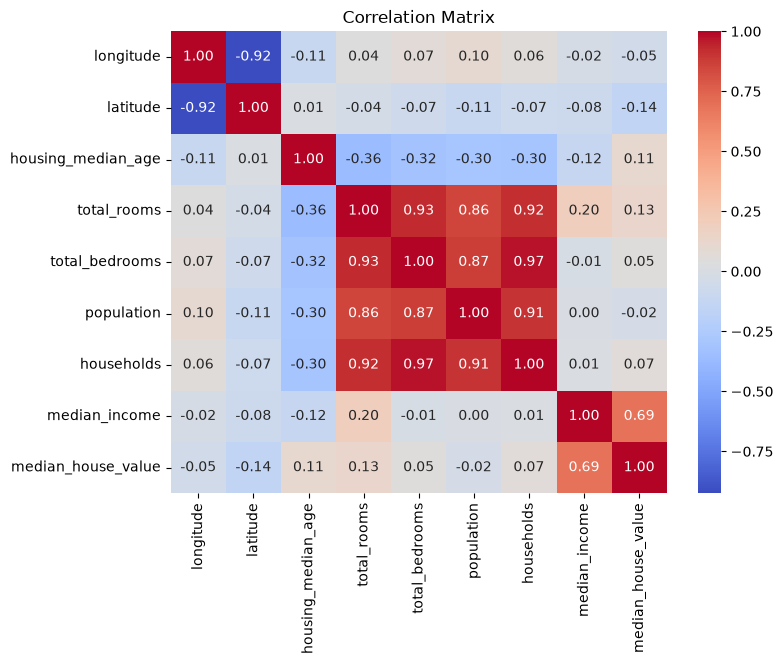

In [89]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

### Correlation Matrix Findings

- **Strongest predictor:** `median_income` (r = 0.69)
- **Severe multicollinearity:** `total_rooms`, `total_bedrooms`, 
  `population`, `households` are highly correlated with each other 
  (r = 0.86-0.98)
- **longitude ↔ latitude:** r = -0.92, reflects CA geography, not an issue
- **Weak predictors:** `housing_median_age`, coordinates individually (|r| < 0.15)

**Implication:** derive ratio features (e.g. `rooms_per_household`) instead 
of using raw room counts; `median_income` is the dominant signal.

In [90]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [91]:
le = LabelEncoder()
df['ocean_proximity'] = le.fit_transform(df['ocean_proximity'])

In [92]:
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [93]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### task3: Train at least two appropriate models and evaluate them with a suitable metric against a baseline.

In [94]:
# --- Baseline: predicts the mean for every row ---
baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train_scaled, y_train)
baseline_preds = baseline.predict(X_test_scaled)

In [95]:
# --- Baseline: predicts the mean for every row ---
baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train_scaled, y_train)
baseline_preds = baseline.predict(X_test_scaled)

In [96]:
# --- Model 1: Linear Regression ---
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

In [97]:
# --- Model 2: Random Forest Regressor ---
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)

In [98]:
# --- Evaluation function ---
def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'Model': name, 'MAE': round(mae, 2), 'RMSE': round(rmse, 2), 'R²': round(r2, 4)}

results = [
    evaluate('Baseline (mean)', y_test, baseline_preds),
    evaluate('Linear Regression', y_test, lr_preds),
    evaluate('Random Forest', y_test, rf_preds),
]

results_df = pd.DataFrame(results)
print(results_df)

               Model       MAE       RMSE      R²
0    Baseline (mean)  90606.85  114485.64 -0.0002
1  Linear Regression  51820.75   71147.87  0.6137
2      Random Forest  32143.64   50199.09  0.8077


### Model Comparison — Baseline vs. Linear Regression vs. Random Forest

| Model | MAE | RMSE | R² |
|---|---|---|---|
| Baseline (mean) | 90,606.85 | 114,485.64 | -0.0002 |
| Linear Regression | 51,820.75 | 71,147.87 | 0.6137 |
| Random Forest | 32,143.64 | 50,199.09 | 0.8077 |

Both models clearly beat the baseline. **Random Forest** performs best on 
every metric (R² = 0.81 vs. 0.61 for Linear Regression), likely because it 
captures non-linear interactions (e.g. location × income) that a linear 
model can't.

**Conclusion:** Random Forest is the better choice — lowest error, highest R².

### task4: Select the better model, justify the choice, and document the full pipeline in a narrated notebook.

**Selected model: Random Forest Regressor**

Random Forest was chosen over Linear Regression and the baseline because it 
achieved the lowest error and highest explained variance on every metric 
(MAE = 32,143.64, RMSE = 50,199.09, R² = 0.8077, vs. Linear Regression's 
R² = 0.6137). This gap is expected: house prices depend on non-linear 
interactions between features (e.g. location combined with income), which 
Random Forest — an ensemble of decision trees — captures naturally, while 
Linear Regression is constrained to linear relationships alone.

Random Forest also required no additional preprocessing tradeoffs 
(e.g. it's robust to unscaled features and mixed feature types), making it 
both the most accurate and the most practical choice for this dataset.